In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import json

In [22]:
def read_csv_folder_dict(folder_path):
    """Return a dictionary with filenames as keys."""
    csv_files = list(Path(folder_path).glob("*.csv"))
    csv_files.sort()
    return {file.stem: pd.read_csv(file) for file in csv_files}


def read_json_folder(folder_path):
    """Read all JSON files from a folder into a dict of objects."""
    json_files = list(Path(folder_path).glob("*.json"))
    json_files.sort()
    json_dict = {file.stem: json.load(open(file)) for file in json_files}
    return json_dict


results_dfs = read_csv_folder_dict(
    "./../../data/experiment_output/fair_irl/exp_results/"
)
info_jsons = read_json_folder("./../../data/experiment_output/fair_irl/exp_info/")

organized_data = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(pd.DataFrame)))
)
organized_info = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
)

for filename in results_dfs:
    weight_adjusts = info_jsons[filename]["WEIGHT_ADJUSTS"]
    dataset = info_jsons[filename]["DATASET"]
    expert = info_jsons[filename]["EXPERT_ALGO"]
    bias_types = info_jsons[filename]["BIAS_TYPES"]
    organized_data[dataset][expert][tuple(bias_types)][tuple(weight_adjusts)] = (
        results_dfs[filename]
    )
    organized_info[dataset][expert][tuple(bias_types)][tuple(weight_adjusts)].append(
        info_jsons[filename]
    )

# Average across all trials for each dataset, expert, bias type, and weight adjustment
averaged_data = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(pd.DataFrame)))
)
averaged_info = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
)
for dataset in organized_info:
    for expert in organized_info[dataset]:
        for bias_types in organized_info[dataset][expert]:
            for weight_adjusts in organized_info[dataset][expert][bias_types]:
                trial_data = organized_data[dataset][expert][bias_types][weight_adjusts]
                average_series = trial_data.mean()
                averaged_data[dataset][expert][bias_types][
                    weight_adjusts
                ] = average_series
                averaged_info[dataset][expert][bias_types][weight_adjusts] = (
                    organized_info[dataset][expert][bias_types][weight_adjusts][0]
                )

In [23]:
measurable_experts = [
    "OptAcc",
    "HardtDemPar",
    "HardtEqOpp",
    "HardtTNRPar",
    "HardtFPRPar",
    "HardtFNRPar",
]
unbiased_types = ()
biased_types = ("perfectly_balanced_redlining",)
unadjusted_weights = ()
adjusted_weights = ("zero_negative_weights",)

data_config_list = []  # (Metric Prefix, Metrix Suffix, bias types, weight adjustments)
# data_config_list.append(("wL_", "", biased_types, unadjusted_weights)) # Original IRL Weights
# data_config_list.append(("wL_", "", biased_types, adjusted_weights)) # Zeroed IRL Weights
# data_config_list.append(("muE_biased_", "_mean", unbiased_types, unadjusted_weights)) # Raw Data FE
# data_config_list.append(("muE_", "_mean", biased_types, unadjusted_weights)) # Biased Demo FE
data_config_list.append(
    ("muL_best_", "", biased_types, unadjusted_weights)
)  # Original IRL FE
data_config_list.append(
    ("muL_best_", "", biased_types, adjusted_weights)
)  # Zeroed IRL FE

measurable_metrics = ["Acc", "DemPar", "EqOpp", "TNRPar", "FPRPar", "FNRPar"]
# measurable_metrics = ["Acc", "DemPar", "EqOpp", "TNRPar", "FPRPar", "FNRPar", "PR_Z0", "PR_Z1", "NR_Z0", "NR_Z1", "TPR_Z0", "TPR_Z1", "TNR_Z0", "TNR_Z1", "FPR_Z0", "FPR_Z1", "FNR_Z0", "FNR_Z1"]
measurable_metric_list = []
for data_config in data_config_list:
    measurable_metric_list.append(
        [data_config[0] + metric + data_config[1] for metric in measurable_metrics]
    )

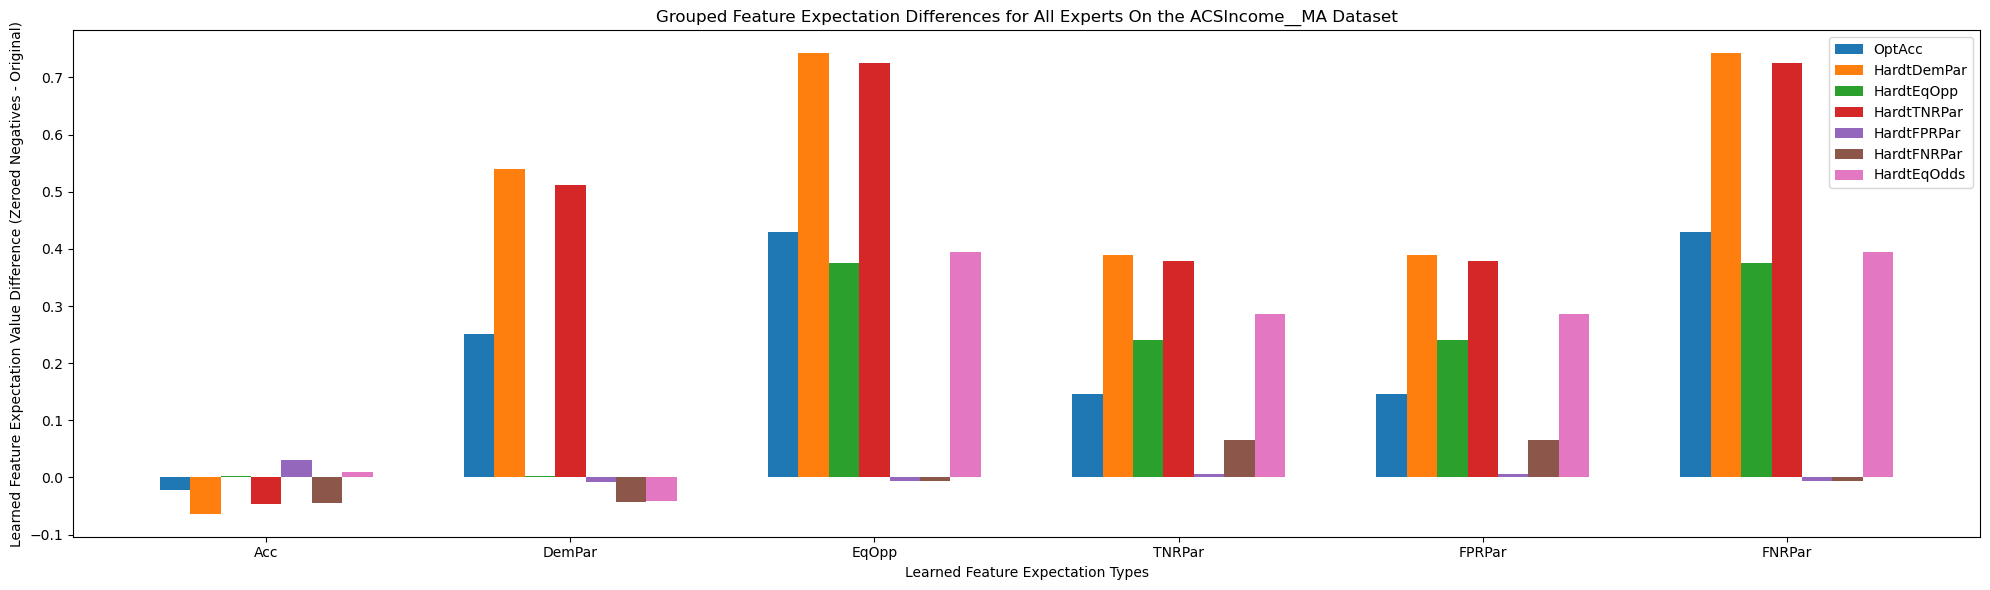

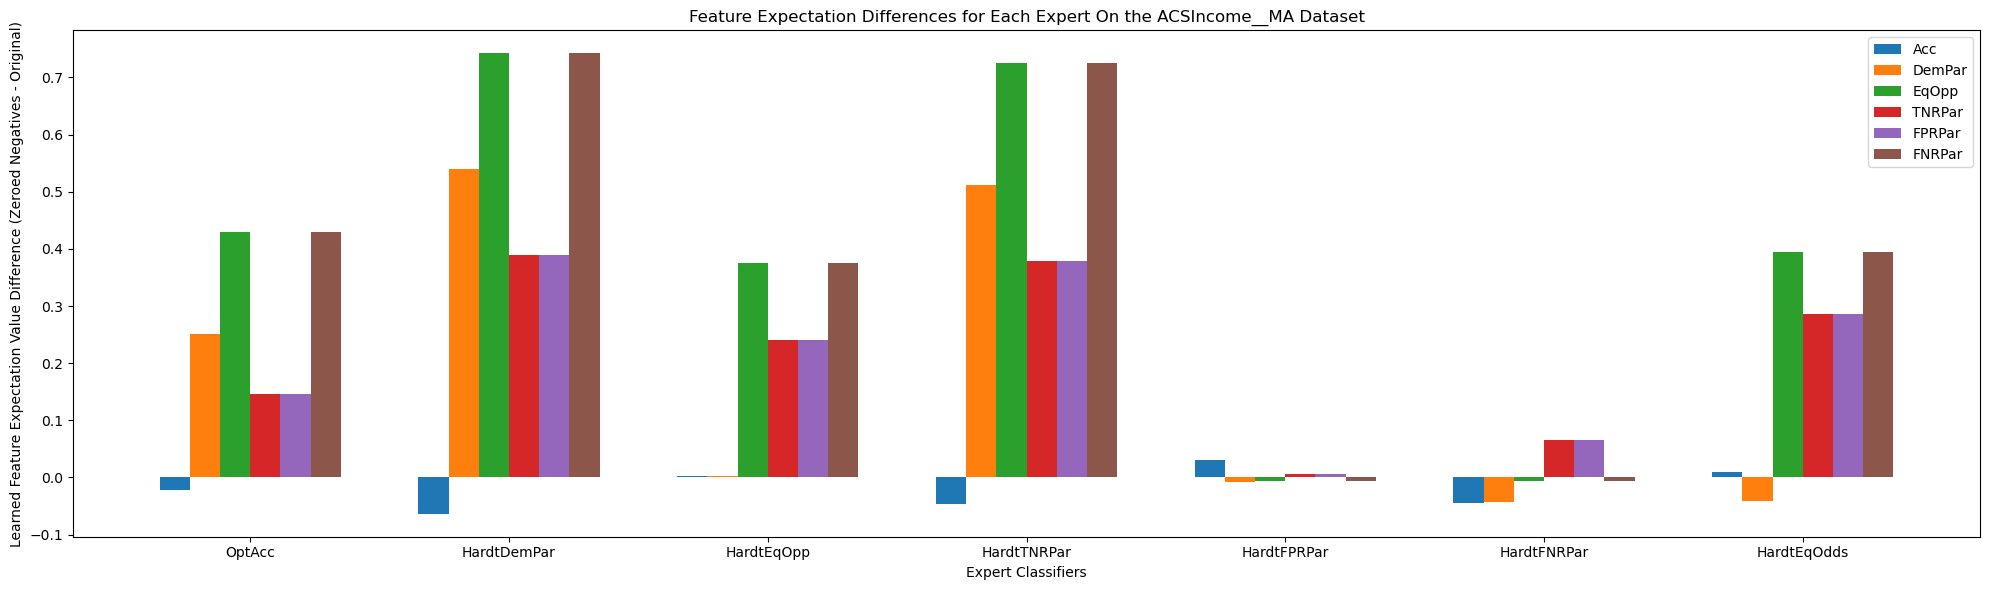

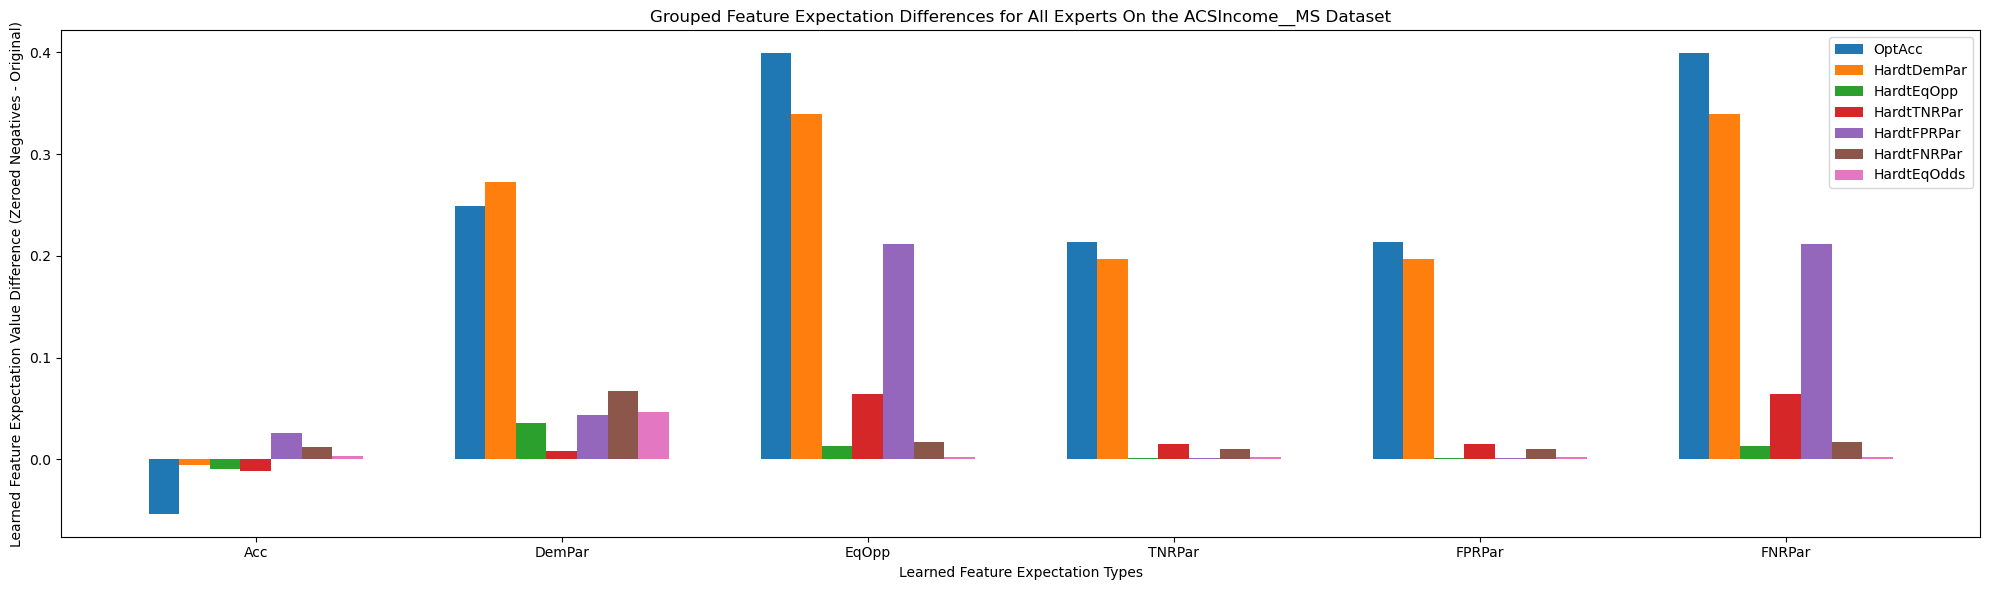

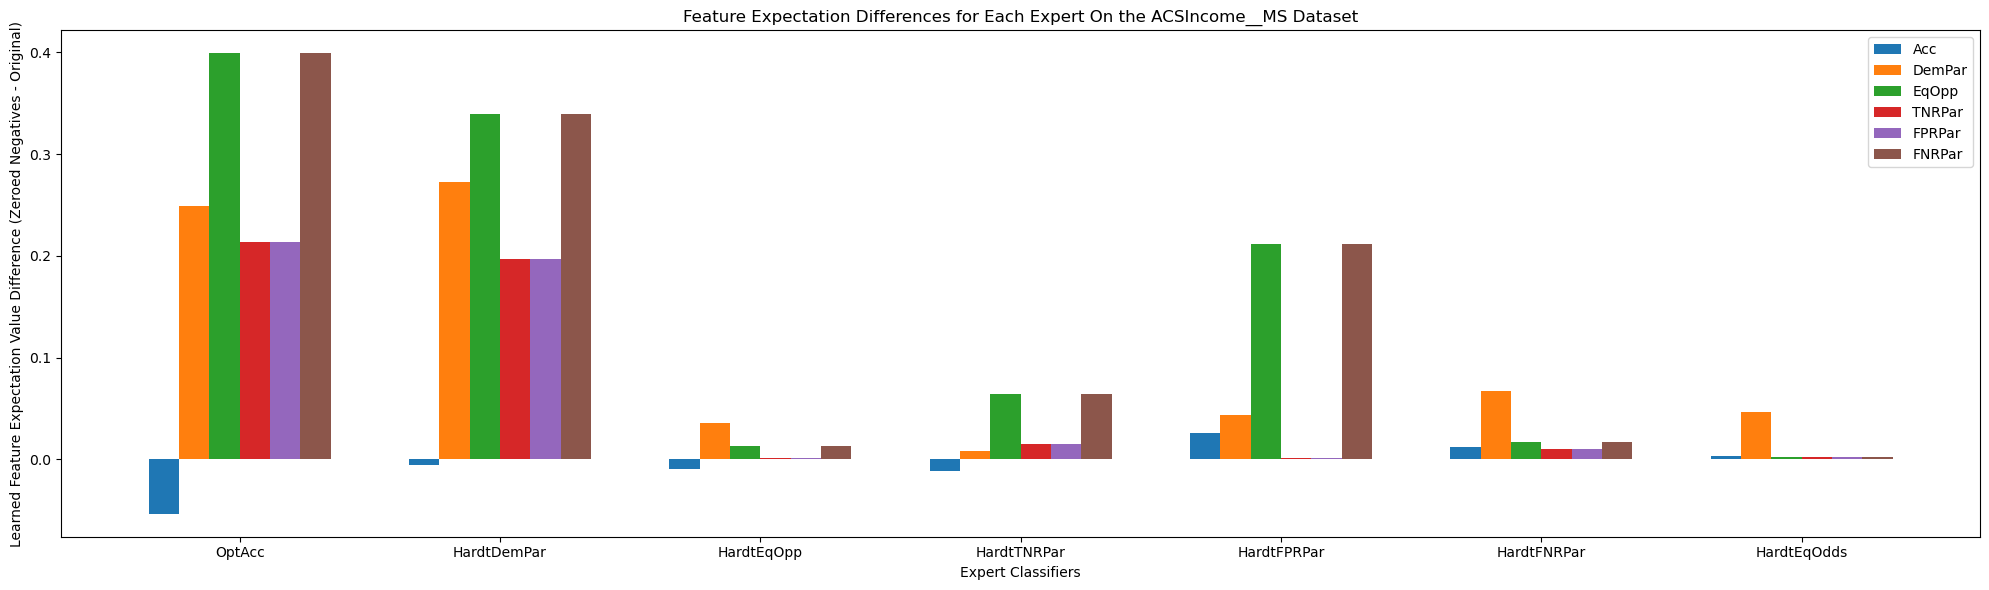

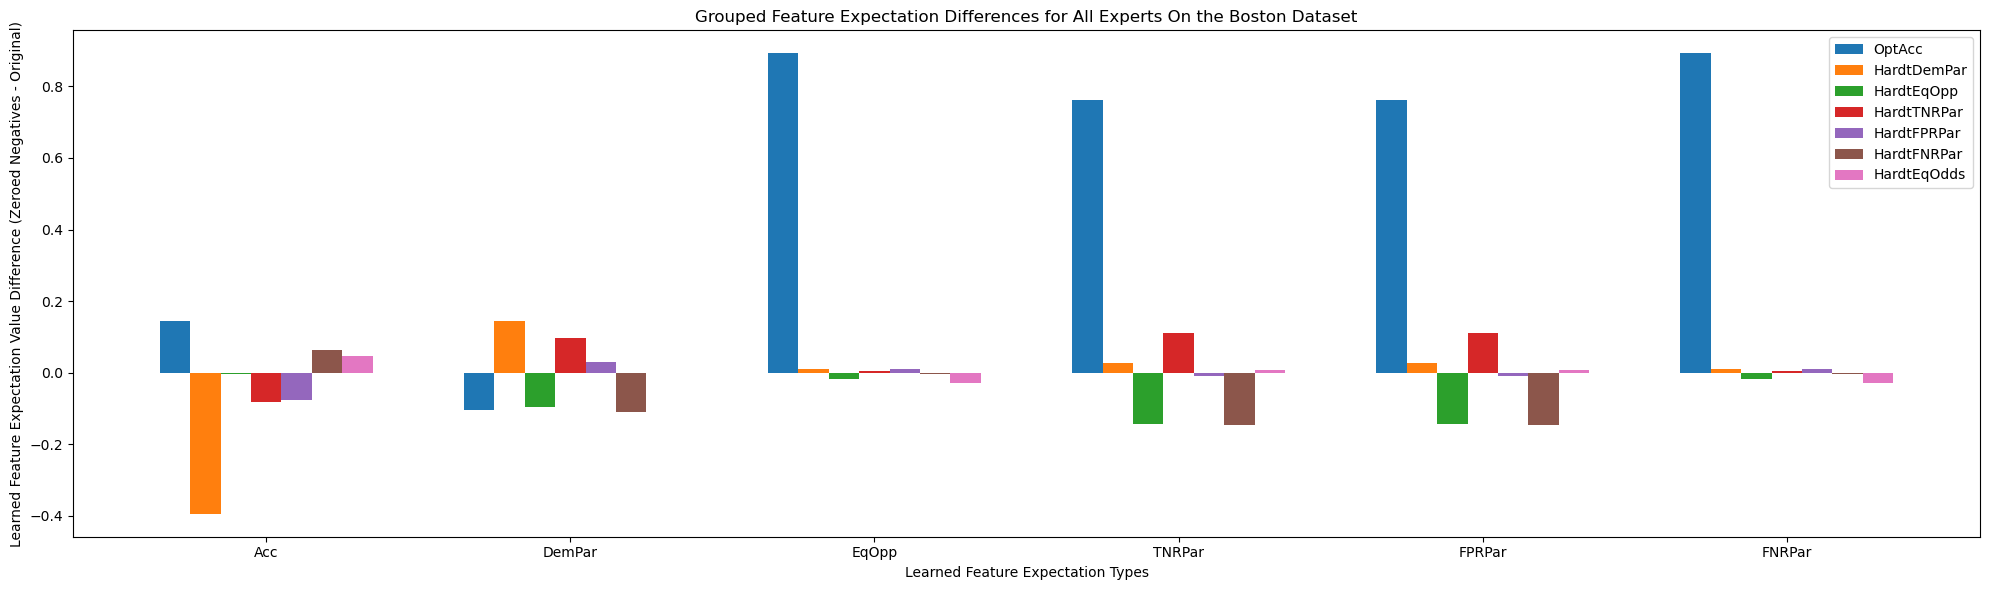

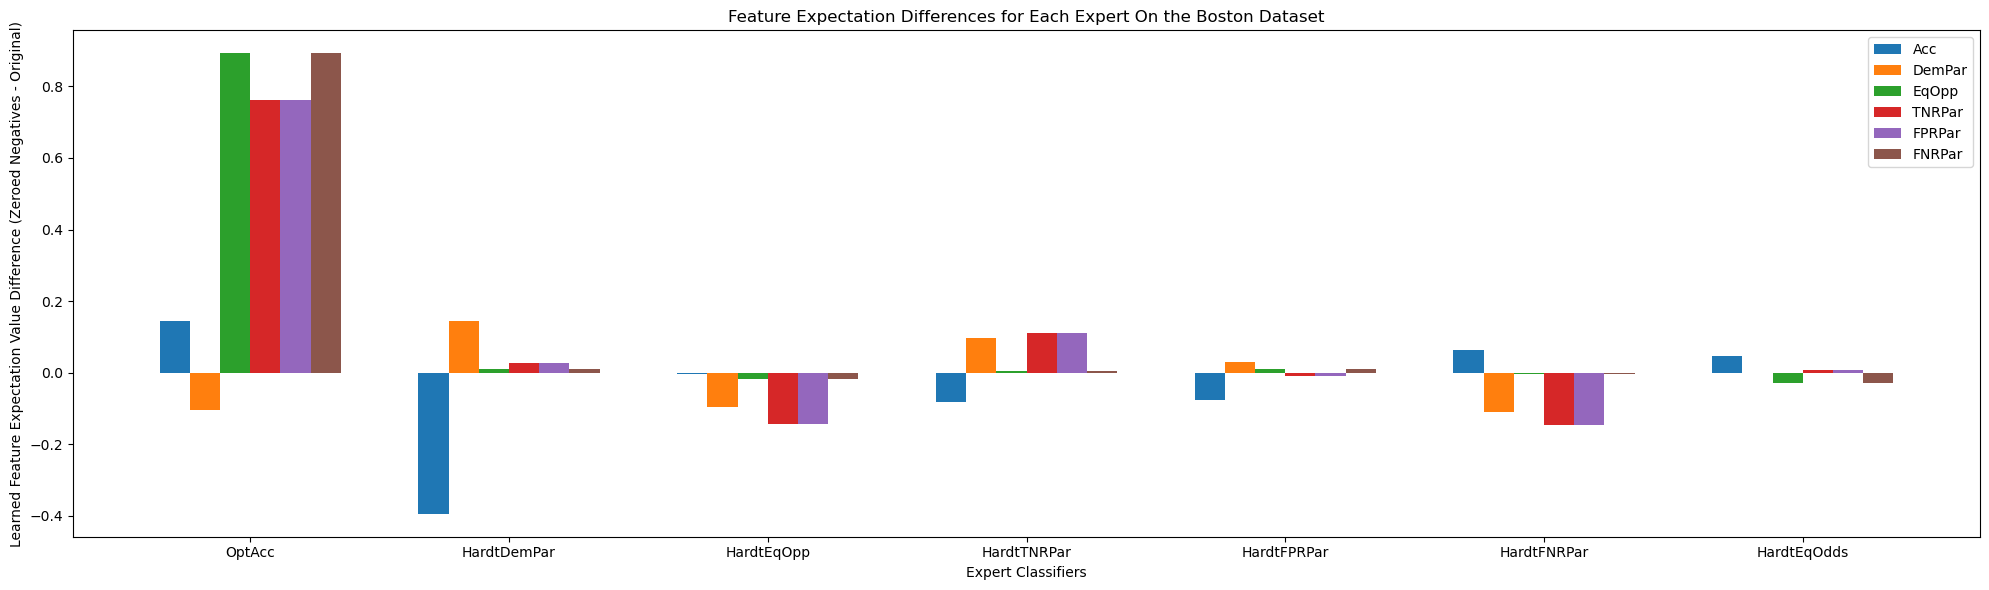

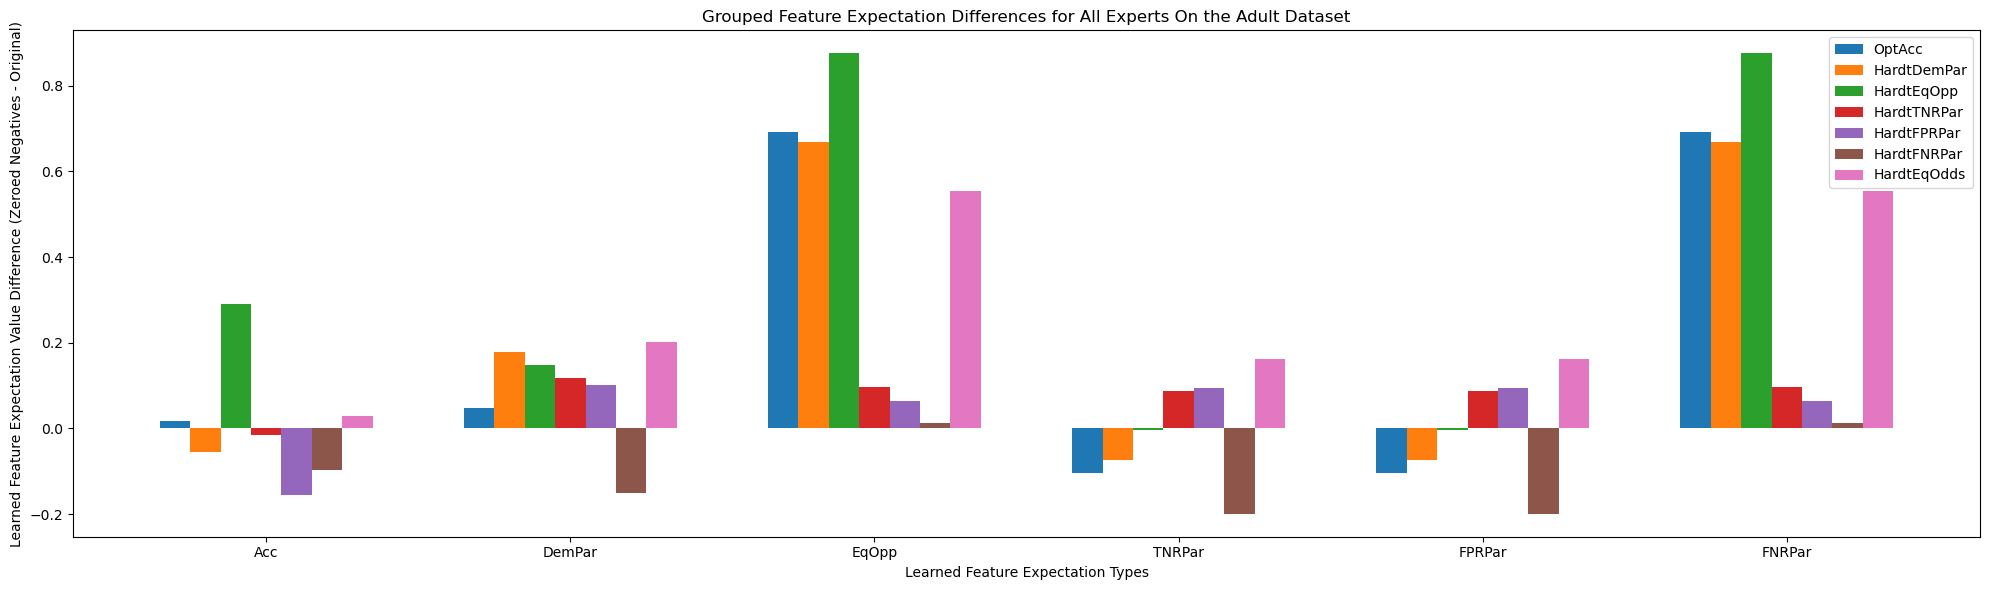

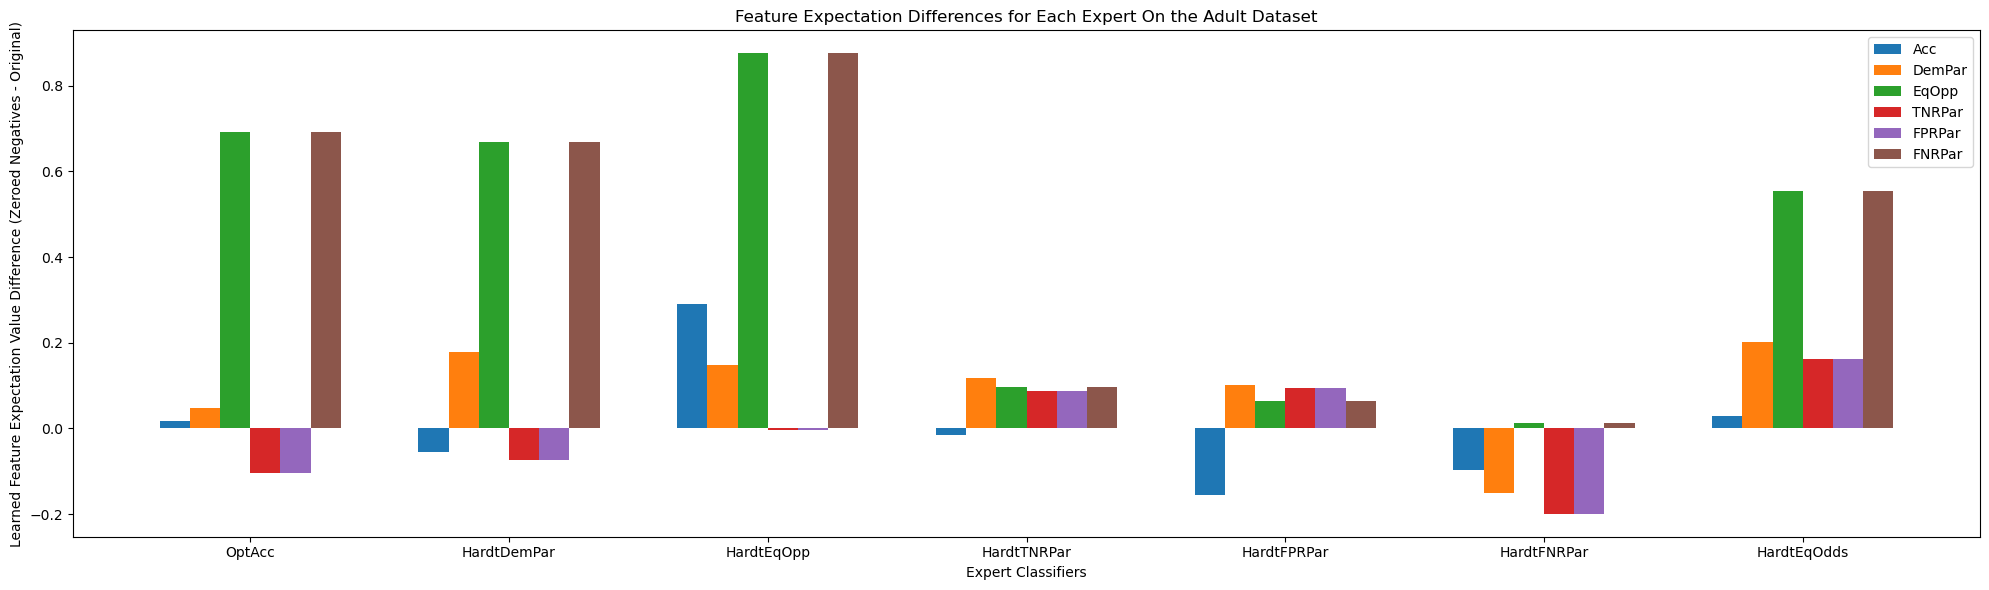

In [24]:
for dataset in averaged_info:
    expert_list = []
    diff_metric_list = []
    for expert in averaged_info[dataset]:
        expert_list.append(expert)
        metric_series_list = []
        for data_config, measurable_metric in zip(
            data_config_list, measurable_metric_list
        ):
            exp_results = averaged_data[dataset][expert][data_config[2]][data_config[3]]
            metric_results = exp_results.loc[measurable_metric]
            metric_results.index = measurable_metrics
            metric_series_list.append(metric_results)
        # # adjusted_weight_series = averaged_data[dataset][expert][biased_types][adjusted_weights]
        # # original_weight_series = averaged_data[dataset][expert][unbiased_types][unadjusted_weights]
        # # adjusted_weight_series = averaged_data[dataset][expert][biased_types][unadjusted_weights]
        # # diff_series = adjusted_weight_series.sub(original_weight_series)
        # # diff_series = adjusted_weight_series
        # index_to_drop = [ind for ind in original_weight_series.index if any(string in ind for string in exclude_metrics)]
        # index_to_drop_2 = [ind for ind in adjusted_weight_series.index if any(string in ind for string in exclude_metrics)]
        # # filtered_diff_series = diff_series.drop(index_to_drop)
        # filtered_orig_series = original_weight_series.drop(index_to_drop)
        # filtered_adju_series = adjusted_weight_series.drop(index_to_drop_2)
        # # wL_inds = [ind for ind in filtered_diff_series.index if ind.startswith(metric_prefix)]
        # muE_inds = [ind for ind in filtered_orig_series.index if ind.startswith(data_config)]
        # muL_inds = [ind for ind in filtered_adju_series.index if ind.startswith(metric_prefix_2)]
        # # diff_wL_series = filtered_diff_series[wL_inds]
        # diff_muE_series = filtered_orig_series[muE_inds]
        # diff_muL_series = filtered_adju_series[muL_inds]
        # diff_muL_series.index = diff_muE_series.index
        diff_sub_series = metric_series_list[1].sub(metric_series_list[0])
        # diff_metric_list.append(diff_wL_series)
        diff_metric_list.append(diff_sub_series)

    col_names = diff_metric_list[0].index.tolist()
    # col_names = [name.removeprefix(data_config) for name in col_names]

    fig, ax = plt.subplots(figsize=(20, 6))

    num_arrays = len(diff_metric_list)
    array_length = len(diff_metric_list[0].index)

    indices = np.arange(array_length)

    bar_width = 0.7 / num_arrays

    for i, arr in enumerate(diff_metric_list):
        ax.bar(
            indices + i * bar_width,
            arr.to_numpy(),
            width=bar_width,
            label=expert_list[i],
        )

    ax.set_xlabel("Learned Feature Expectation Types")
    ax.set_ylabel(
        "Learned Feature Expectation Value Difference (Zeroed Negatives - Original)"
    )
    ax.set_title(
        f"Grouped Feature Expectation Differences for All Experts On the {dataset} Dataset"
    )
    ax.set_xticks(indices + bar_width * (num_arrays - 1) / 2)
    ax.set_xticklabels(col_names)
    ax.legend()

    plt.tight_layout()
    plt.show()

    trans_diff_wL_list = np.array(diff_metric_list)
    trans_diff_wL_list = trans_diff_wL_list.T
    trans_diff_wL_list = [
        trans_diff_wL_list[i] for i in range(trans_diff_wL_list.shape[0])
    ]

    fig, ax = plt.subplots(figsize=(20, 6))

    indices = np.arange(num_arrays)

    bar_width = 0.7 / array_length

    for i, arr in enumerate(trans_diff_wL_list):
        ax.bar(indices + i * bar_width, arr, width=bar_width, label=col_names[i])

    ax.set_xlabel("Expert Classifiers")
    ax.set_ylabel(
        "Learned Feature Expectation Value Difference (Zeroed Negatives - Original)"
    )
    ax.set_title(
        f"Feature Expectation Differences for Each Expert On the {dataset} Dataset"
    )
    ax.set_xticks(indices + bar_width * (array_length - 1) / 2)
    ax.set_xticklabels(expert_list)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # selected_expert_list = []
    # selected_wL_name_list = []
    # selected_diff_wL_single = []
    # for i, (expert, diff_wL) in enumerate(zip(expert_list, diff_metric_list)):
    #     if (expert in measurable_experts) and (measurable_weights[i] in diff_wL.index):
    #         selected_inds = [ind for ind in diff_wL.index if ind in measurable_weights]
    #         selected_diff_wL = diff_wL[selected_inds]
    #         selected_diff_wL_single.append(selected_diff_wL[measurable_weights[i]])
    #         selected_expert_list.append(expert)
    #         selected_wL_name_list.append(measurable_weights[i])

    # fig, ax = plt.subplots(figsize=(20, 6))

    # indices = np.arange(len(selected_diff_wL_single))

    # bar_width = 0.7 / len(selected_diff_wL_single)

    # # for i, arr in enumerate(selected_diff_wL_single):
    # bars = ax.bar(selected_expert_list, selected_diff_wL_single, label=selected_wL_name_list)

    # ax.set_xlabel("Expert Classifiers")
    # ax.set_ylabel("Learned Feature Expectation Value Difference (Zeroed Negatives - Original)")
    # ax.set_title(f'Feature Expectation Differences Corresponding to Each Expert On the {dataset} Dataset')
    # # ax.set_xticks(indices + bar_width * (array_length - 1) / 2)
    # # ax.bar_label(bars, labels=selected_expert_list)
    # ax.legend()

    # plt.tight_layout()
    # plt.show()